In [1]:
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import nnls
import scipy.linalg
import matplotlib.pyplot as plt
from iminuit import Minuit
from scipy.optimize import nnls, minimize

from pyPAS.core.lt import MultiGaussianRF, PASLifetime, TimeResolution
from pyPAS.lifetime.generator import generate_random_lt_spectrum, generate_analytical_lt_spectrum
from pyPAS.lifetime.model import LifetimeModel
from pyspectrum import Spectrum
np.random.seed(42)

# system parmeters 

material

In [2]:
# characteristic lifetime distribution
dτ  = 5e-4
fine_τ_grid = np.arange(dτ, 5, dτ)

gauss_I_τ = np.vstack(np.array([0.40,  0.50, 0.10]))
gauss_τ = np.vstack(np.array([0.125, 0.45, 3.0]))
gauss_σ_τ = np.vstack(np.array([0.0015, 0.05, 0.3]))   # width in τ (ns)
#
#gauss_I_τ = np.vstack(np.array([0.25,  0.2, 0.25, .3]))
#gauss_τ = np.vstack(np.array([0.14, 0.185, 0.3, 1]))
#gauss_σ_τ = gauss_τ*0.1


true_τ_distribution = (gauss_I_τ / np.sqrt(2*np.pi*gauss_σ_τ**2) * np.exp(-(gauss_τ - fine_τ_grid) ** 2 / (2*gauss_σ_τ**2))).sum(axis=0)

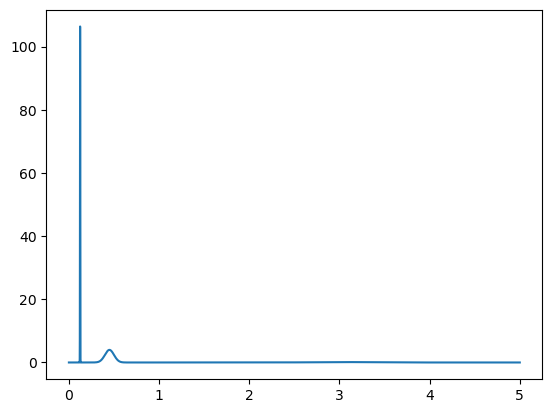

In [3]:
plt.plot(fine_τ_grid, true_τ_distribution)

In [4]:
irf_sigma = np.array([0.250/(2*np.sqrt(2*np.log(2)))])
IRF = MultiGaussianRF(irf_sigma, np.ones_like(irf_sigma), np.zeros_like(irf_sigma))

In [5]:
lt_model = LifetimeModel("simulation", lifetimes=fine_τ_grid, intensities=true_τ_distribution)
time_step = 5e-3 # 5 picosecond
time = np.arange(-2, 40, time_step)
bg_frac = 0.1

expected_background = bg_frac/(time[-1]-time[0]) * np.ones_like(time)
analytical_spectrum = generate_analytical_lt_spectrum(time, lt_model, IRF, bg_frac)
random_spectrum = generate_random_lt_spectrum(time, lt_model, IRF, bg_frac, int(1e7))

In [6]:
# resolution function using response to impulse
impulse = np.zeros_like(time)
impulse[np.where(time>0)[0][0]] = 1/(time[1] - time[0])

res_fun = IRF.convolve(impulse,time)

(-1.0, 20.0)

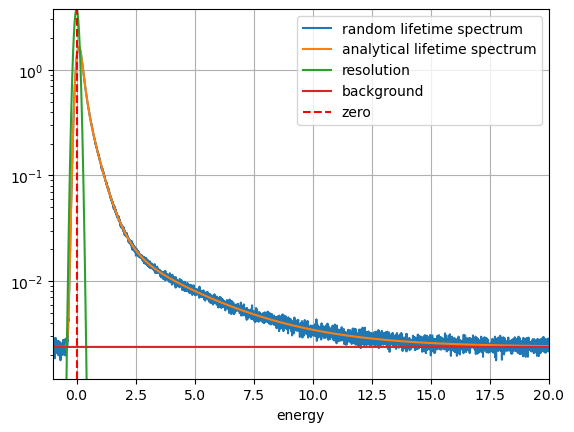

In [7]:
random_normalizer = random_spectrum.lifetime.integrate('energy').item()
(random_spectrum.lifetime/random_normalizer).plot(label='random lifetime spectrum', yscale='log')
(analytical_spectrum.lifetime).plot(label='analytical lifetime spectrum', yscale='log')

plt.plot(time, res_fun, label='resolution')
plt.plot(time, expected_background, label='background')
plt.axvline(0, color='red', label='zero', ls='--')
plt.legend()
plt.ylim([expected_background[0]/2, np.max([res_fun.max(), analytical_spectrum.lifetime.max()])])
plt.grid()
plt.xlim([-1, 20])

# Inversion

In [8]:
from pyPAS.optimizer.lifetime.inversion.utils import _response_matrix
from matplotlib.colors import LogNorm
from pyPAS.optimizer.lifetime.inversion import LifetimeInvert
from pyPAS.optimizer.lifetime.inversion.tikhonov import TikhonovRegularization
from pyPAS.optimizer.lifetime.inversion.maximum_entropy import MaximalEntropyInversion

In [9]:
dτ = 2.5e-2
τ_grid = np.arange(dτ, 5, dτ)

dt = 5e-3
time_grid = np.arange(-2, 40, dt)

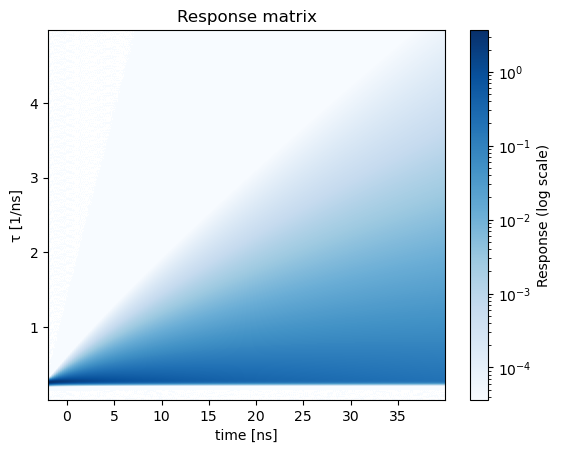

In [10]:
RM = _response_matrix(τ_grid, time_grid, IRF)
vmax = RM.max()
vmin = vmax / 1e5   # 5 orders of magnitude

plt.imshow(RM,
           cmap='Blues',
           origin='lower',
           extent=[time.min(), time.max(),
                   τ_grid.min(), τ_grid.max()],
           aspect='auto',
           norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(label='Response (log scale)')
plt.title('Response matrix')
plt.xlabel('time [ns]')
plt.ylabel('τ [1/ns]')
plt.show()

In [11]:
tinvert = TikhonovRegularization(random_spectrum.lifetime.energy.values, τ_grid)
q, res = tinvert.invert(random_spectrum, initial_alpha=1e-5, bg_est=random_spectrum.lifetime.counts[-1000:].mean())

In [12]:
# the resulted optimization gives gives integral of 1 as expected
np.trapz(q, τ_grid), res

(1.0012511332470408,
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.09083692039640301
        x: [-1.022e+01]
      nit: 1
    direc: [[ 1.000e+00]]
     nfev: 29)

In [13]:
q[40:].sum()/q.sum()

0.0948879206139402

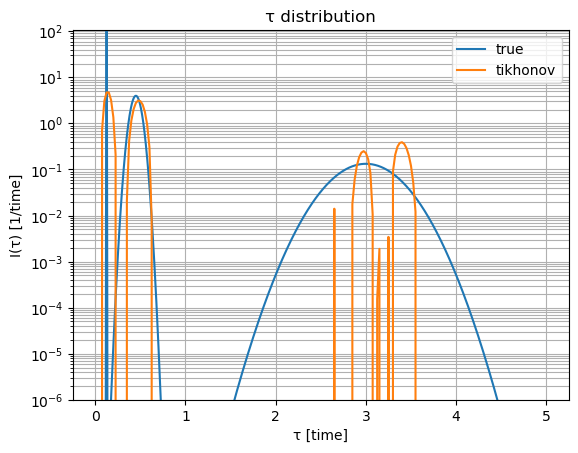

In [14]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.yscale("log")
plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()

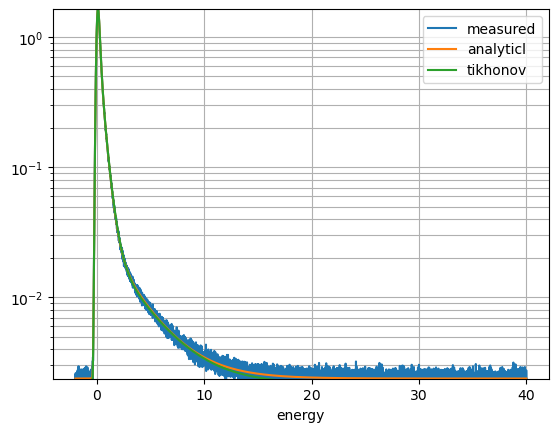

In [15]:
tikhonov_result_model = LifetimeModel('', τ_grid, q/np.trapz(q,τ_grid))
tikhonov_lifetime = generate_analytical_lt_spectrum(time,
                                                    tikhonov_result_model,
                                                    resolution=IRF,
                                                    background_fraction=0)
tikhonov_lifetime.lifetime.counts *= np.trapz(random_spectrum.lifetime.counts, random_spectrum.lifetime.energy)
tikhonov_lifetime.lifetime.counts += random_spectrum.lifetime.counts[-1000:].mean()
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
(tikhonov_lifetime.lifetime/tikhonov_lifetime.lifetime.integrate('energy')).plot(yscale='log', label='tikhonov')

plt.grid(which="both")

plt.ylim([random_spectrum.lifetime.counts[-1000:].mean()/random_spectrum.lifetime.integrate('energy'),(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).max()])
plt.legend()

MELT

In [16]:
melt = MaximalEntropyInversion(random_spectrum.lifetime.energy.values, τ_grid)

In [17]:
a1, melt_q1 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-4, bg_est=random_spectrum.lifetime.counts[-1000:].mean())

In [18]:
a2, melt_q2 = melt.invert(pals=random_spectrum, maxiter=400, noise_level = 1e-5, bg_est=random_spectrum.lifetime.counts[-1000:].mean())

In [19]:
a1, a2

(5.747955616203849e-09, 8.943784453921907e-08)

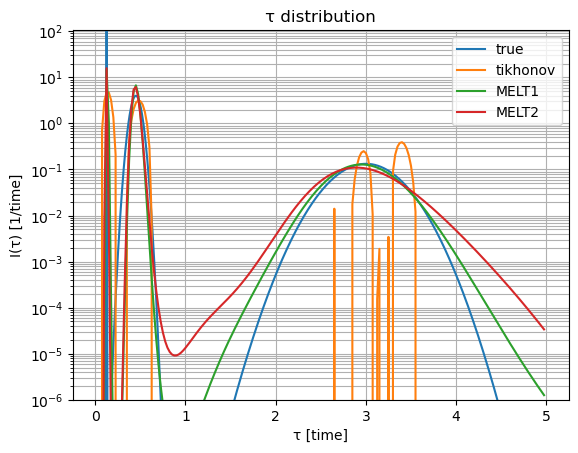

In [20]:
plt.plot(fine_τ_grid, true_τ_distribution, label="true")
plt.plot(τ_grid, q/np.trapz(q,τ_grid), label='tikhonov')
plt.plot(τ_grid, melt_q1/np.trapz(melt_q1,τ_grid), label='MELT1')
plt.plot(τ_grid, melt_q2/np.trapz(melt_q2,τ_grid), label='MELT2')

plt.yscale("log")
#plt.xscale("log")

plt.ylim([1e-6, true_τ_distribution.max()])
plt.grid(which="both")

plt.title("τ distribution")
plt.ylabel("I(τ) [1/time]")
plt.xlabel("τ [time]")

plt.legend()
plt.show()

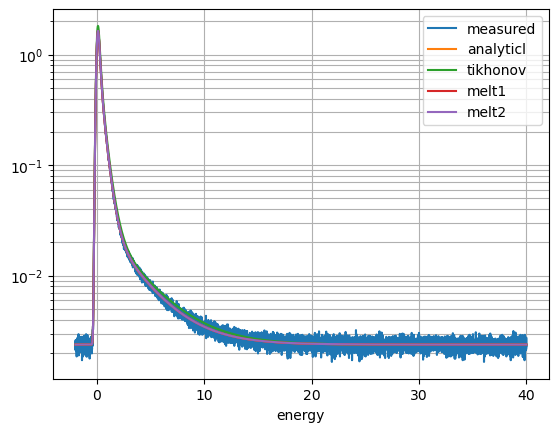

In [21]:
melt_result_model1 = LifetimeModel('', τ_grid, melt_q1/np.trapz(melt_q1,τ_grid))
melt_result_model2 = LifetimeModel('', τ_grid, melt_q2/np.trapz(melt_q2,τ_grid))

melt_lifetime1 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model1,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
melt_lifetime2 = generate_analytical_lt_spectrum(time,
                                                    melt_result_model2,
                                                    resolution=IRF,
                                                    background_fraction=bg_frac)
(random_spectrum.lifetime/random_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='measured')
(analytical_spectrum.lifetime/analytical_spectrum.lifetime.integrate('energy')).plot(yscale='log', label='analyticl')
(tikhonov_lifetime.lifetime/random_spectrum.lifetime.integrate('energy')).plot(label='tikhonov')
melt_lifetime1.lifetime.plot(label='melt1')
melt_lifetime2.lifetime.plot(label='melt2')
plt.grid(which="both")


plt.legend()

In [22]:
(((random_spectrum.lifetime.counts - melt_lifetime2.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.9932578673938431

In [23]:
(((random_spectrum.lifetime.counts - melt_lifetime1.lifetime.counts)/(1+random_spectrum.lifetime.counts)).sum())/len(random_spectrum.lifetime.counts)

0.9932578711705611